




























# Fit theoretical curve to the data and extract EOM parameters

**Note; this notebook does no data collection within it, only analysis.** This makes more 
sense on a day to day basis. **To use** this notebook, do the following:

1. Run `EOM_V_Sweep.py` and input `y` when the script is done to store the detector trace `.csv`.
2. Take note of the `.csv` name from the output terminal (for example `20260918_234439_Detector_Traces.csv`. Note, that particular
`.csv` file will always remain in this directory as an example).
3. Ensure the correct `.csv` file string is in the code cell below.
4. Click `Run All`! It should work. Let me (Peter) know if it doesn't work.

In [4]:
import pandas as pd

# ENSURE THAT THIS N MATCHES THE N IN EOM_V_sweep.py
N= 30
directory = "C:\\Users\\nanometa\\Documents\\QKD_Code\\data\\eoms\\9_28_26\\pulsed_EOM_stability\\500 kHz\\"
file = "20260928_224722_255952_Detector_Traces.csv"
filepath = directory + file
df = pd.read_csv(filepath)

Trace 0 Fit Parameters (A, k1, k2, phi, C): [ 2.12730074e+02  7.83644900e-03  8.07585100e-03 -2.23843736e+00
  8.68999425e+01]
Trace 0 R^2:  0.9421172235146387
Trace 1 Fit Parameters (A, k1, k2, phi, C): [ 1.81091111e+02  7.50678400e-03  7.89196000e-03 -7.19600917e-01
  1.23224861e+02]
Trace 1 R^2:  0.9201747440092625


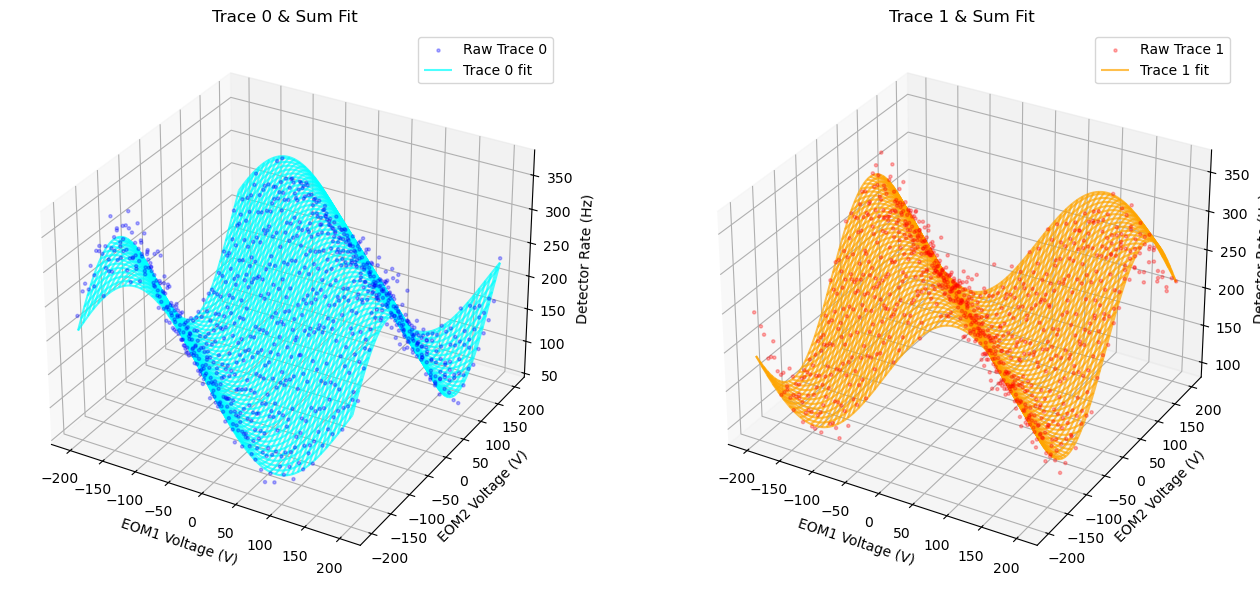

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 2. Load the detector trace data
# df comes from reading above
# df = pd.read_csv("20260916_220636_Detector_Traces.csv")
z0 = df['Rate0_Hz'].values
z1 = df['Rate1_Hz'].values

# 3. Define the updated 2D interference fitting function
def new_eom_model(xy, A, k1, k2, phi, C):
    x, y = xy
    return A * (np.sin(k1 * x + k2 * y + phi)**2) + C

# 4. Execute the curve fitting for both traces
# Initial parameter guesses: [Amplitude, k1, k2, phi, Offset]
p0_guess0 = [np.max(z0) - np.min(z0), 0.01, 0.01, 0, np.min(z0)]
try:
    popt0, pcov0 = curve_fit(new_eom_model, (signalarray0, signalarray1), z0, p0=p0_guess0)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 0 failed to converge")

p0_guess1 = [np.max(z1) - np.min(z1), 0.01, 0.01, 0, np.min(z1)]
try:
    popt1, pcov1 = curve_fit(new_eom_model, (signalarray0, signalarray1), z1, p0=p0_guess1)
except RuntimeError:
    # Fallback guess if optimization fails to converge
    print("Fitting to Trace 1 failed to converge")

# CALCULATING R^2 VALUES

# Calculate the predicted Z values using the optimized parameters
z0_fit = new_eom_model((signalarray0, signalarray1), *popt0)
# Calculate the Residual Sum of Squares (SS_res)
ss_res0 = np.sum((z0 - z0_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot0 = np.sum((z0 - np.mean(z0))**2)
# Compute R^2
r_squared0 = 1 - (ss_res0 / ss_tot0)

# Calculate the predicted Z values using the optimized parameters
z1_fit = new_eom_model((signalarray0, signalarray1), *popt1)
# Calculate the Residual Sum of Squares (SS_res)
ss_res1 = np.sum((z1 - z1_fit)**2)
# Calculate the Total Sum of Squares (SS_tot)
ss_tot1 = np.sum((z1 - np.mean(z1))**2)
# Compute R^2
r_squared1 = 1 - (ss_res1 / ss_tot1)


print(f"Trace 0 Fit Parameters (A, k1, k2, phi, C): {np.round(popt0, 9)}")
print(f"Trace 0 R^2: ", r_squared0)
print(f"Trace 1 Fit Parameters (A, k1, k2, phi, C): {np.round(popt1, 9)}")
print(f"Trace 1 R^2: ", r_squared1)

# 5. Generate a high-resolution meshgrid for smooth surface plotting
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))
Z0_fit = new_eom_model((X, Y), *popt0)
Z1_fit = new_eom_model((X, Y), *popt1)

# 6. Initialize the 3D plot with two subplots
fig = plt.figure(figsize=(14, 6))

# Subplot 1: Trace 0
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(signalarray0, signalarray1, z0, c='blue', s=5, alpha=0.3, label='Raw Trace 0')
ax1.plot_wireframe(X, Y, Z0_fit, color='cyan', alpha=0.7, label='Trace 0 fit')
ax1.set_xlabel('EOM1 Voltage (V)')
ax1.set_ylabel('EOM2 Voltage (V)')
ax1.set_zlabel('Detector Rate (Hz)')
ax1.set_title('Trace 0 & Sum Fit')
ax1.legend()

# Subplot 2: Trace 1
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(signalarray0, signalarray1, z1, c='red', s=5, alpha=0.3, label='Raw Trace 1')
ax2.plot_wireframe(X, Y, Z1_fit, color='orange', alpha=0.7, label='Trace 1 fit')
ax2.set_xlabel('EOM1 Voltage (V)')
ax2.set_ylabel('EOM2 Voltage (V)')
ax2.set_zlabel('Detector Rate (Hz)')
ax2.set_title('Trace 1 & Sum Fit')
ax2.legend()

plt.tight_layout()
plt.show()

# Decide EOM voltages for BB84 photon manipulation

In [6]:
import numpy as np
from scipy.optimize import minimize_scalar

# Assume popt0 is populated from your prior curve_fit execution
k1 = popt0[1]
k2 = popt0[2]
phi = popt0[3]

# Derived V_pi parameters based on your interference model
ALICE_EOM_VPI = np.pi / (2 * k1)
BOB_EOM_VPI = np.pi / (2 * k2)

# The fundamental voltage periods corresponding to an invariant phase shift (pi in sin^2 argument).
# Shifting any EOM voltage by this amount leaves the detector rates entirely invariant.
ALICE_PERIOD = 2 * ALICE_EOM_VPI
BOB_PERIOD = 2 * BOB_EOM_VPI

NAlice = 4
NBob = 2

def wrap_voltage(v, period):
    """Folds any voltage into the fundamental [-period/2, period/2] interval."""
    return (v + period / 2) % period - period / 2

def objective_general(BobV0):
    # Base zero-point relation: k1*Va + k2*Vb + phi = 0
    AliceV0 = -(phi + k2 * BobV0) / k1
    
    # Generate the ideal continuous sequences
    Va_raw = AliceV0 + np.arange(NAlice) * ALICE_EOM_VPI / 2
    Vb_raw = BobV0 - np.arange(NBob) * BOB_EOM_VPI / 2
    
    # Exploit the phase periodicity to wrap each state independently.
    # This automatically accounts for all possible optimal permutations of the states.
    Va_wrapped = wrap_voltage(Va_raw, ALICE_PERIOD)
    Vb_wrapped = wrap_voltage(Vb_raw, BOB_PERIOD)
    
    # L2 norm minimization of all applied voltages to strictly minimize EOM strain
    return np.sum(Va_wrapped**2) + np.sum(Vb_wrapped**2)

# Because the underlying physics is periodic, we only need to optimize over exactly one Bob period.
result = minimize_scalar(
    objective_general, 
    bounds=(-BOB_PERIOD/2, BOB_PERIOD/2), 
    method='bounded'
)

optimal_BobV0 = result.x
optimal_AliceV0 = -(phi + k2 * optimal_BobV0) / k1

# Wrap the final output states into the optimal gauge
AliceEOMVoltages = wrap_voltage(optimal_AliceV0 + np.arange(NAlice) * ALICE_EOM_VPI / 2, ALICE_PERIOD)
BobEOMVoltages = wrap_voltage(optimal_BobV0 - np.arange(NBob) * BOB_EOM_VPI / 2, BOB_PERIOD)

print(f"Wrapped Alice Voltages (V): {np.round(AliceEOMVoltages, 3)}")
print(f"Wrapped Bob Voltages (V): {np.round(BobEOMVoltages, 3)}")

Wrapped Alice Voltages (V): [-155.146  -54.922   45.302  145.526]
Wrapped Bob Voltages (V): [ 38.712 -58.54 ]


EOM0Voltages =  [-155.14561935  -54.92189298   45.30183338  145.52555975]
EOM1Voltages =  [ 38.71239388 -58.5402928 ]


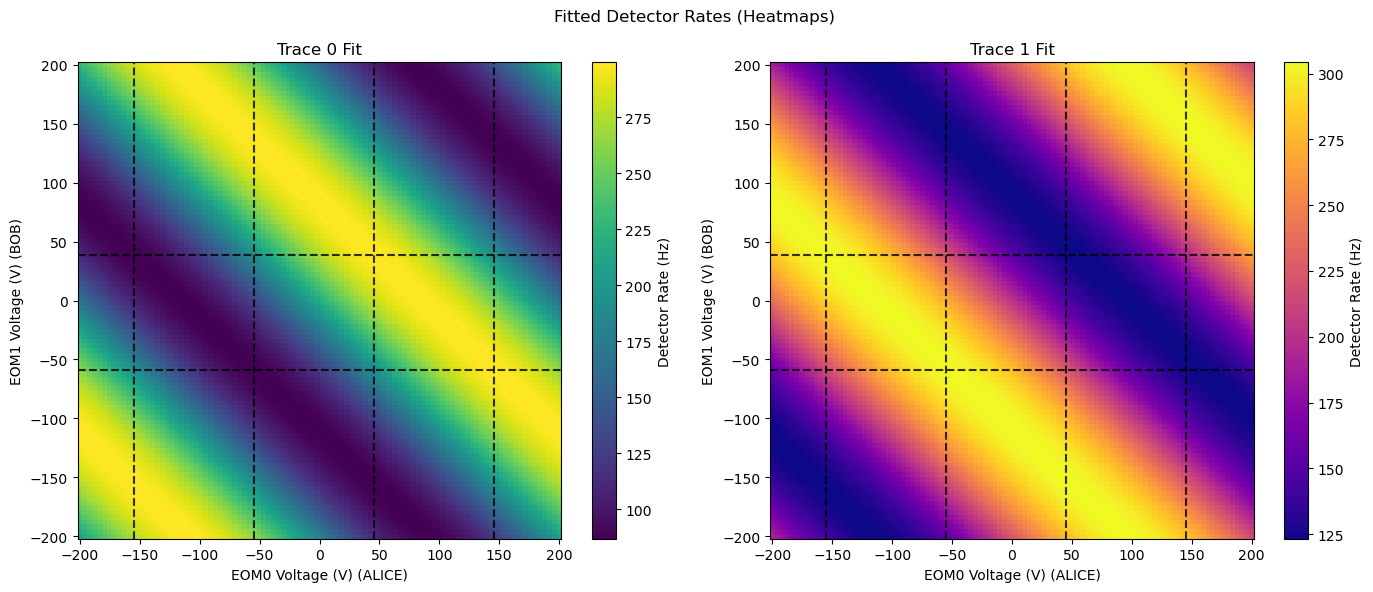

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Generate a meshgrid for plotting
X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))

# 4. Calculate the corresponding Z (Rate) values
Z0_fit = new_eom_model((X, Y), *popt0)
Z1_fit = new_eom_model((X, Y), *popt1)

# 5. Initialize the 2D subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 6. Plot using pcolormesh for the heatmaps
c1 = ax1.pcolormesh(X, Y, Z0_fit, cmap='viridis', shading='auto')
c2 = ax2.pcolormesh(X, Y, Z1_fit, cmap='plasma', shading='auto')
fig.colorbar(c1, ax=ax1, label='Detector Rate (Hz)')
fig.colorbar(c2, ax=ax2, label='Detector Rate (Hz)')

for voltage in AliceEOMVoltages:

    ax1.axvline(x=voltage, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax2.axvline(x=voltage, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

for voltage in BobEOMVoltages:

    ax1.axhline(y=voltage, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax2.axhline(y=voltage, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

print('EOM0Voltages = ', AliceEOMVoltages)
print('EOM1Voltages = ', BobEOMVoltages)

# 8. Format the axes and titles
ax1.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax1.set_ylabel('EOM1 Voltage (V) (BOB)')
ax1.set_title('Trace 0 Fit')

ax2.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax2.set_ylabel('EOM1 Voltage (V) (BOB)')
ax2.set_title('Trace 1 Fit')

fig.suptitle('Fitted Detector Rates (Heatmaps)')

# 9. Display the plot
plt.tight_layout()
plt.show()

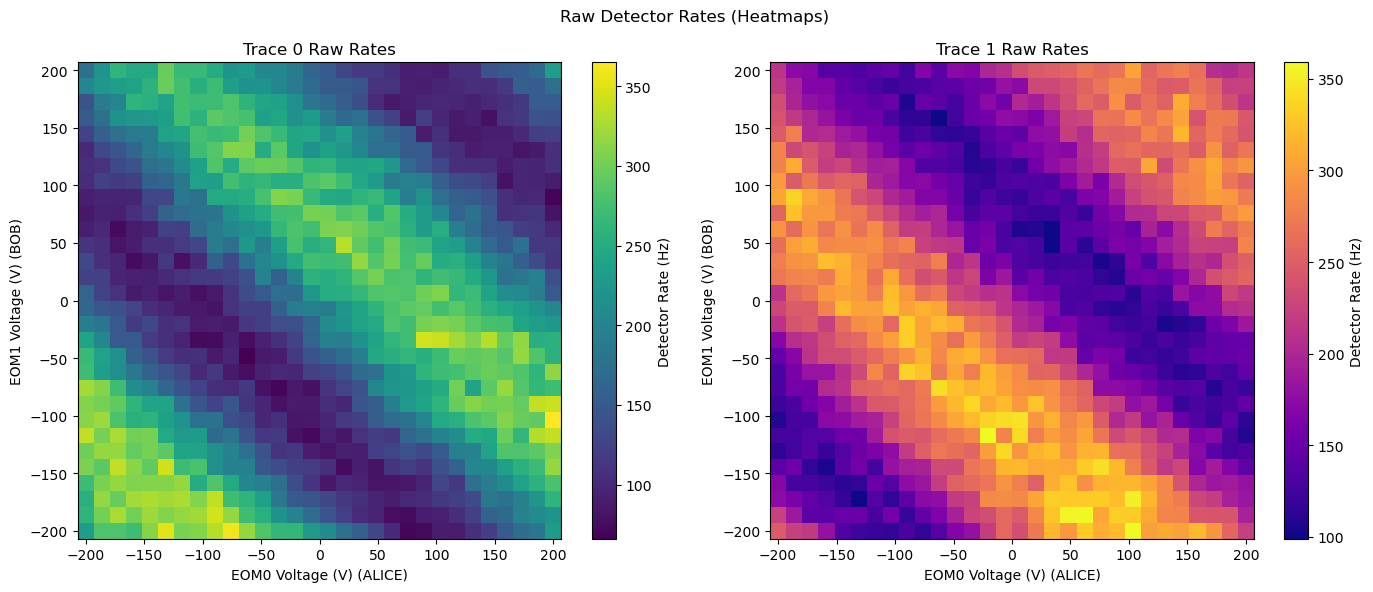

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Determine grid dimension N and create the matching voltage meshgrid
N = int(np.sqrt(len(z0)))  # Derives N directly from data length (e.g., 60)
v_sweep = np.linspace(-200, 200, N)
X, Y = np.meshgrid(v_sweep, v_sweep)

# 2. Reshape the 1D raw rates into 2D matrices (Bob = rows, Alice = columns)
Z0_raw = z0.reshape((N, N))
Z1_raw = z1.reshape((N, N))

# 3. Initialize the 2D subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 4. Plot the raw data heatmaps
c1 = ax1.pcolormesh(X, Y, Z0_raw, cmap='viridis', shading='auto')
c2 = ax2.pcolormesh(X, Y, Z1_raw, cmap='plasma', shading='auto')

fig.colorbar(c1, ax=ax1, label='Detector Rate (Hz)')
fig.colorbar(c2, ax=ax2, label='Detector Rate (Hz)')

# 5. Format axes, titles, and layout
ax1.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax1.set_ylabel('EOM1 Voltage (V) (BOB)')
ax1.set_title('Trace 0 Raw Rates')

ax2.set_xlabel('EOM0 Voltage (V) (ALICE)')
ax2.set_ylabel('EOM1 Voltage (V) (BOB)')
ax2.set_title('Trace 1 Raw Rates')

fig.suptitle('Raw Detector Rates (Heatmaps)')

plt.tight_layout()
plt.show()

# Plot four by four BB84 protocol logic matrix

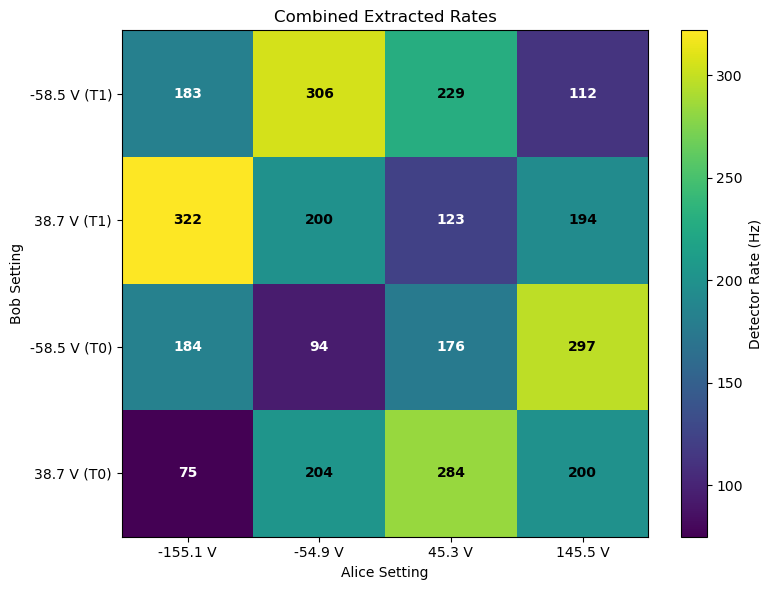

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 3. Extract the 8 closest points into 2x4 matrices
rate0_grid = np.zeros((2, 4))
rate1_grid = np.zeros((2, 4))

for i, v1_ideal in enumerate(BobEOMVoltages):
    for j, v0_ideal in enumerate(AliceEOMVoltages):
        distances = (signalarray0 - v0_ideal)**2 + (signalarray1 - v1_ideal)**2
        idx = np.argmin(distances)
        
        rate0_grid[i, j] = z0[idx]
        rate1_grid[i, j] = z1[idx]

# 4. Combine the grids into a single 4x4 matrix
# np.vstack puts rate0_grid at indices 0,1 and rate1_grid at 2,3.
# With origin='lower', indices 2,3 (Trace 1) appear above indices 0,1 (Trace 0).
combined_grid = np.vstack((rate0_grid, rate1_grid))

# Combine Y-axis labels to distinguish the traces
combined_y_labels = [f"{v:.1f} V (T0)" for v in BobEOMVoltages] + [f"{v:.1f} V (T1)" for v in BobEOMVoltages]

# 5. Plot the 4x4 heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(combined_grid, origin='lower', cmap='viridis', aspect='auto')

# 6. Add colorbar shared for both traces
fig.colorbar(im, ax=ax, label='Detector Rate (Hz)')

# 7. Format axes and annotate values
ax.set_xticks(np.arange(len(AliceEOMVoltages)))
ax.set_yticks(np.arange(len(combined_y_labels)))

x_labels = [f"{v:.1f} V" for v in AliceEOMVoltages]

# Label ticks with rounded voltage values and trace identifiers
ax.set_xticklabels(x_labels)
ax.set_yticklabels(combined_y_labels)

ax.set_xlabel('Alice Setting')
ax.set_ylabel('Bob Setting')
ax.set_title('Combined Extracted Rates')

# Annotate each cell with the exact count rate
threshold = np.max(combined_grid) * 0.6  # Threshold for text color contrast
for i in range(combined_grid.shape[0]):
    for j in range(combined_grid.shape[1]):
        val = combined_grid[i, j]
        text_color = "white" if val < threshold else "black"
        ax.text(j, i, f"{int(val)}", ha="center", va="center", color=text_color, fontweight='bold')

# 8. Display the plot
plt.tight_layout()
plt.show()




In [10]:
import numpy as np
import plotly.graph_objects as go

# --- Assume N, z0, z1, AliceEOMVoltages, BobEOMVoltages are defined upstream ---

# 1. Define the measurement logic arrays
v_sweep = np.linspace(-200, 200, N)
signalarray0 = np.tile(v_sweep, N)
signalarray1 = np.repeat(v_sweep, N)

# 2 & 3. Extract the closest points into 2x4 matrices
rate0_grid = np.zeros((2, 4))
rate1_grid = np.zeros((2, 4))

for i, v1_ideal in enumerate(BobEOMVoltages):
    for j, v0_ideal in enumerate(AliceEOMVoltages):
        distances = (signalarray0 - v0_ideal) ** 2 + (signalarray1 - v1_ideal) ** 2
        idx = np.argmin(distances)

        rate0_grid[i, j] = z0[idx]
        rate1_grid[i, j] = z1[idx]

# 4. Combine grids into a single 4x4 matrix
combined_grid = np.vstack((rate0_grid, rate1_grid))

# Swapping to get into literature form
combined_grid[[0,2]] = combined_grid[[2,0]]
combined_grid[[1,3]] = combined_grid[[3,1]]

# 5. Build the Plotly 3D Mesh Plot
fig = go.Figure()

num_y, num_x = combined_grid.shape
dx = 0.65
dy = 0.65

# Fix the maximum Z value so the color scale is uniform across all pillars
z_max_global = np.max(combined_grid) if np.max(combined_grid) > 0 else 1

# Standard cube triangulation (12 triangles connecting the 8 vertices)
i_tris = [0, 0, 4, 4, 0, 0, 3, 3, 0, 0, 1, 1]
j_tris = [1, 2, 5, 6, 1, 5, 2, 6, 3, 7, 2, 6]
k_tris = [2, 3, 6, 7, 5, 4, 6, 7, 7, 4, 6, 5]

for j in range(num_y):
    for i in range(num_x):
        z_val = combined_grid[j, i]
        if z_val <= 0:
            continue
            
        # Define the 8 corners of the pillar (Bottom 4, Top 4)
        x_verts = [i-dx/2, i+dx/2, i+dx/2, i-dx/2, i-dx/2, i+dx/2, i+dx/2, i-dx/2]
        y_verts = [j-dy/2, j-dy/2, j+dy/2, j+dy/2, j-dy/2, j-dy/2, j+dy/2, j+dy/2]
        z_verts = [0, 0, 0, 0, z_val, z_val, z_val, z_val]
        
        fig.add_trace(go.Mesh3d(
            x=x_verts,
            y=y_verts,
            z=z_verts,
            i=i_tris,
            j=j_tris,
            k=k_tris,
            intensity=z_verts,      # Interpolates color based on Z-height
            colorscale='Viridis',   
            cmin=0,                 # Anchor base color (blue) to Z=0
            cmax=z_max_global,      # Anchor peak color (yellow) to global max
            showscale=False,        
            flatshading=True,       # Keeps pillar walls flat rather than smoothed
            lighting=dict(facenormalsepsilon=0, ambient=0.7, diffuse=0.8),
            hoverinfo='skip'
        ))

# 6. Styling to match the reference format
x_labels = [f"{v:.1f} V" for v in AliceEOMVoltages]
combined_y_labels = [f"{v:.1f} V (T0)" for v in BobEOMVoltages] + [
    f"{v:.1f} V (T1)" for v in BobEOMVoltages
]

fig.update_layout(
    scene=dict(
        xaxis=dict(
            tickvals=np.arange(num_x),
            ticktext=x_labels,
            showgrid=True,
            gridcolor='lightgray',
            backgroundcolor='white',
            title=''
        ),
        yaxis=dict(
            tickvals=np.arange(num_y),
            ticktext=combined_y_labels,
            showgrid=True,
            gridcolor='lightgray',
            backgroundcolor='white',
            title=''
        ),
        zaxis=dict(
            showgrid=True,
            gridcolor='lightgray',
            backgroundcolor='white',
            title=''
        ),
        aspectratio=dict(x=1, y=1, z=0.8),
        camera=dict(
            # Using an orthographic projection flattens perspective distortion, 
            # which is heavily favored for quantitative 3D bar charts in literature.
            projection=dict(type="orthographic"),
            eye=dict(x=1.5, y=-1.5, z=1.2) 
        )
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    paper_bgcolor='white',
    showlegend=False
)

fig.show()